In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import minimize_scalar
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
data = pd.read_csv('../datasets/heart.csv', header=0)

target_col_name = data.columns[-1]
X_raw = data.drop(columns=[target_col_name])
y_raw = data[target_col_name]

x_train_raw, _, y_train_raw, _ = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

y_train = np.where(y_train_raw == 0, -1, 1)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_raw)

x_train_biased = np.c_[x_train_scaled, np.ones(x_train_scaled.shape[0])]

n_samples, n_features = x_train_biased.shape

print(f"Data prepared: {n_samples} samples, {n_features} features (including bias)")

Data prepared: 242 samples, 14 features (including bias)


In [3]:
def calculate_loss(w, X, y):
    """
    Calculates the total logistic loss.
    L(w) = sum( log(1 + exp(-y_j * (w @ x_j))) )
    """
    scores = y * (X @ w)
    log_loss_per_sample = np.logaddexp(0, -scores)
    return np.sum(log_loss_per_sample)

In [4]:
model = LogisticRegression(penalty=None, fit_intercept=False, solver='lbfgs', max_iter=1000)
model.fit(x_train_biased, y_train)

w_sklearn = model.coef_[0]
L_star = calculate_loss(w_sklearn, x_train_biased, y_train)

print(f"scikit-learn baseline loss L* = {L_star:.4f}")

scikit-learn baseline loss L* = 84.2745


In [5]:
def objective_for_coord_i(alpha, i, w_current, X, y):
    """
    This is the 1D objective function we give to minimize_scalar.
    It calculates the total loss if we *only* change w[i] to `alpha`.
    """
    w_temp = w_current.copy()
    w_temp[i] = alpha
    return calculate_loss(w_temp, X, y)

In [6]:
w = np.zeros(n_features)

# Set number of cycles (a "cycle" is one full pass through all coordinates)
num_cycles = 10
loss_history = [calculate_loss(w, x_train_biased, y_train)]

In [7]:
print("Running Coordinate Descent...")
for cycle in range(num_cycles):
    # (i) Cyclic coordinate choice: loop from 0 to n_features-1
    for i in range(n_features):
        
        # (ii) Set new value: find the best value for w[i]
        result = minimize_scalar(
            objective_for_coord_i, 
            args=(i, w, x_train_biased, y_train)
        )
        
        # Update our w vector with the new best value
        w[i] = result.x
        
        # Record loss after *every single coordinate update*
        loss_history.append(result.fun)

print("Coordinate Descent Finished.")
print(f"Final Coordinate Descent loss = {loss_history[-1]:.4f}")

Running Coordinate Descent...
Coordinate Descent Finished.
Final Coordinate Descent loss = 84.2745


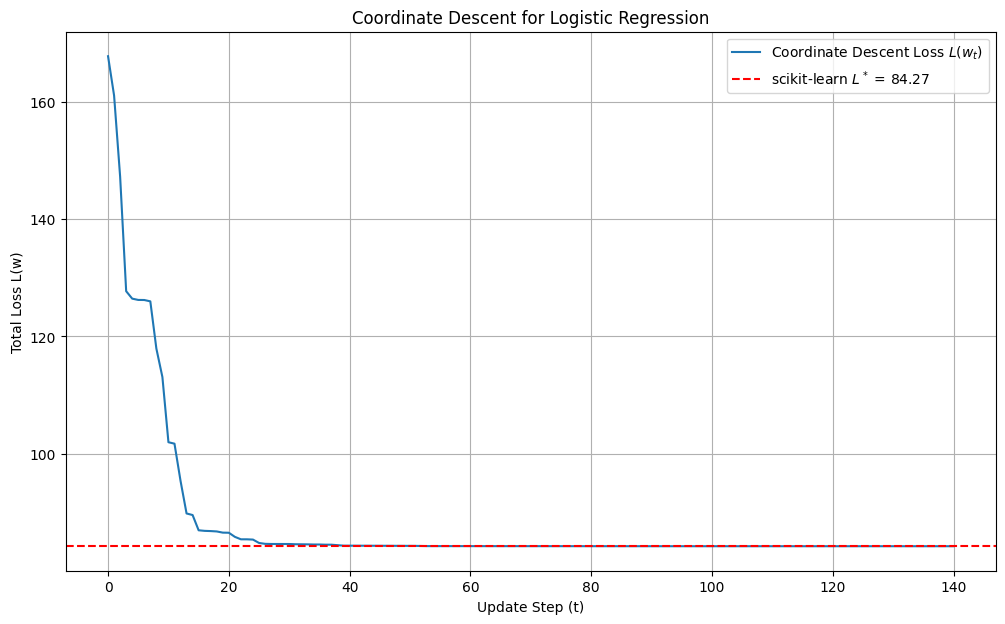

In [8]:
plt.figure(figsize=(12, 7))
plt.plot(loss_history, label="Coordinate Descent Loss $L(w_t)$")
plt.axhline(y=L_star, color='r', linestyle='--', label=f"scikit-learn $L^*$ = {L_star:.2f}")

plt.xlabel("Update Step (t)")
plt.ylabel("Total Loss L(w)")
plt.title("Coordinate Descent for Logistic Regression")
plt.legend()
plt.grid(True)